In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize 
import sympy as sp
from sklearn.metrics import r2_score

sigma = 0.7472*(10**-11) #m, diametro de la molecula de deuterio
Na = 6.022*(10**23) #atom/mol
k = 1.380649*10**-23 #J/K

1. Estimacion de sigma y de epsilon para modelo de pozo cuadrado, con la integral de mayer

epsilon_0: 36.248462
a_0:  11092.96
Optimization terminated successfully.
         Current function value: 919.306207
         Iterations: 113
         Function evaluations: 236
[ 5.43726930e+01 -1.76643525e-08]
epsilon (J): 54.372693000028775
a (m):  -1.7664352453032205e-08


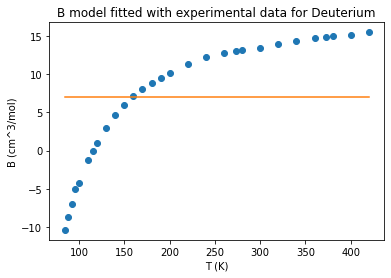

ValueError: Found input variables with inconsistent numbers of samples: [29, 100]

In [15]:
def B(parameters, T):
    epsilon, a = parameters
    return 2*np.pi*Na*((sigma**3)/3 - ((a**3)/3 - (sigma**3)/3)*(1-np.exp(-epsilon/(k*T))))


calc_SSE = lambda parameters, T, Bo: 0.5 * np.dot(Bo - B(parameters, T), Bo - B(parameters, T)) #Bo -> dato experimental

def fit():
    df = pd.read_excel('Datos Deuterio.xlsx')
    T_data = df['T'].to_numpy() # K
    B_data = df['B'].to_numpy() # ml/mol = cm^3/mol

    epsilon_0 = 36.248462 #Arbitrario
    print("epsilon_0:", epsilon_0)
    a_0 = 11092.96 #Arbitrario
    print("a_0: ", a_0)
    parameters_0 = [epsilon_0, a_0]

    settings = {'disp': True} #"settings" is a dictionary to configurate the minimize function. 'disp': True is use to see algorithm performance information
    # result = minimize(calc_SSE, parameters_0, args=(T_data, B_data),
    #                     options=settings, method='BFGS') #This Method is an extention of Newton's method
    

    result = minimize(calc_SSE, parameters_0, args=(T_data, B_data),
                        options=settings, method='Nelder-Mead') 

    print(result.x) #See the object structure that minimze return
    epsilon, a = result.x #Write the values into variables
    print("epsilon (J):", epsilon)
    print("a (m): ", a)

    
    T_plot = np.linspace(min(T_data), max(T_data), 100)
    B_model = B((epsilon, a), T_plot)


    plt.figure()
    plt.plot(T_data, B_data, 'o')
    plt.plot(T_plot, B_model) 
    plt.ylabel('B (cm^3/mol)')
    plt.xlabel('T (K)')
    plt.title('B model fitted with experimental data for Deuterium')
    plt.show()

    print(r2_score(B_data, B_model))

    return epsilon, a

#Note that fit_Arrhenius function does not have an end line. The code lines indented to the left are outside the function. Like this line (73) used for call the function.   
epsilon, a = fit()

2. Estimacion de m y de epsilon con la ecuacion general de modelos de potencial intermolecular, con la integral de mayer

In [13]:
r = sp.symbols('r') #r (distance) is the a variable
m = sp.symbols('m')
epsilon2 = sp.symbols('epsilon2')
T = sp.symbols('T')
gamma = (epsilon2*(m/(m-6))*(m/6)**(6/(m-6)))*((sigma/r)**m - (sigma/r)**6)
exp = sp.exp(-1*gamma/(k*T)) * r**2
result = sp.integrate(exp, (r, 0, sp.oo))
b2 = sp.lambdify((epsilon2, m, T), 2*np.pi*Na*result, modules =['scipy', 'numpy'])
b2_vector = np.vectorize(b2)

def B2(parameters, T):
    epsilon, m = parameters
    return b2_vector(epsilon, m, T)


calc_SSE2 = lambda parameters, Temp, Bo: np.sum(Bo - B2(parameters, Temp))**2  #Bo -> dato experimental

epsilon_0: 5.004640281183801e-22
m_0:  4.1481760271700515e-29


<lambdifygenerated-3>:2: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return 3.78373419198355e+24*quad(lambda r: r**2*exp(1.26048562341219e-44*epsilon2*m*m**(6/(m - 6))/(6**(6/(m - 6))*T*m*r**6 - 6*6**(6/(m - 6))*T*r**6))*exp(-7.24297051603992e+22*7.472e-12**m*epsilon2*m*m**(6/(m - 6))*(r**(-1.0))**m/(6**(6/(m - 6))*T*m - 6*6**(6/(m - 6))*T)), 0, PINF)[0]


[-1.26352864e-19  1.67615404e-27]
epsilon (J): -1.263528637457903e-19
m:  1.6761540372155226e-27


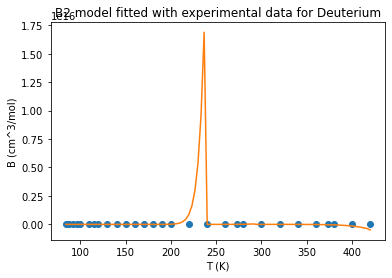

In [ ]:
def fit():
    df = pd.read_excel('Datos Deuterio.xlsx')
    T_data = df['T'].to_numpy() # K
    B_data = df['B'].to_numpy() # ml/mol = cm^3/mol

    epsilon_0 = 36.248462*k #Arbitrario
    print("epsilon_0:", epsilon_0)
    m_0 = 11092.96*epsilon_0*sigma #Arbitrario
    print("m_0: ", m_0)
    parameters_0 = [epsilon_0, m_0]

    settings = {'disp': True} #"settings" is a dictionary to configurate the minimize function. 'disp': True is use to see algorithm performance information
    # result = minimize(calc_SSE, parameters_0, args=(T_data, B_data),
    #                     options=settings, method='BFGS') #This Method is an extention of Newton's method
    
    result = minimize(calc_SSE2, parameters_0, args=(T_data, B_data),
                        options=settings, method='Nelder-Mead') 

    print(result.x) #See the object structure that minimze return
    epsilon2, m = result.x #Write the values into variables
    print("epsilon (J):", epsilon2)
    print("m: ", m)

    T_plot = np.linspace(min(T_data), max(T_data), 100)
    B_model = B2((epsilon2, m), T_plot)


    plt.figure()
    plt.plot(T_data, B_data, 'o')
    plt.plot(T_plot, B_model) 
    plt.ylabel('B (cm^3/mol)')
    plt.xlabel('T (K)')
    plt.title('B2 model fitted with experimental data for Deuterium')
    plt.show()

    
    print(r2_score(B_data, B_model))

    return epsilon2, m
  
epsilon2, m = fit()


3. Encontrar las constantes de una ecuacion con el punto critico, y con virial